# ESG Classification Model for Institutional Wealth Management

Supervised ML pipeline classifying publicly listed corporations into four ESG tiers (Loser, Normal, Winner, Champion). Compares Logistic Regression and Random Forest classifiers with ROC/AUC analysis, class imbalance correction, and feature importance ranking.

**Module:** Machine Learning, AI and Big Data in Finance — MSc Finance & Financial Technology, Henley Business School

### Dependencies
```
pandas, numpy, matplotlib, seaborn, scikit-learn, openpyxl, imbalanced-learn
```

---

### Notebook Structure
- **Section 1** — Exploratory Data Analysis and Data Quality Assessment
- **Section 2** — Machine Learning Model Development and Evaluation

---
## Setup — Package Installation & Imports

In [1]:
# import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import sklearn
import imblearn
import openpyxl

# display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("All imports successful ✅")

All imports successful ✅


---
## Section 1: Exploratory Data Analysis and Data Quality Assessment
> *Briefing the Head of Wealth Management on the quality and reliability of the underlying data.*

In [2]:
# load the training and test datasets
from pathlib import Path

train = pd.read_excel("training_data.xlsx")
test  = pd.read_excel("test_data.xlsx")

print(f"Training dataset : {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test dataset     : {test.shape[0]:,} rows x {test.shape[1]} columns")

Training dataset : 2,000 rows x 17 columns
Test dataset     : 1,000 rows x 17 columns


### 1.1 Dataset Overview

In [3]:
# check the shape and data types of each column
print("=== TRAINING DATASET ===")
print(f"Rows: {train.shape[0]}  |  Columns: {train.shape[1]}")
print()
print(train.dtypes)

=== TRAINING DATASET ===
Rows: 2000  |  Columns: 17

FEAT_ENV1      int64
FEAT_ENV2    float64
FEAT_ENV3      int64
FEAT_ENV4      int64
FEAT_ENV5      int64
FEAT_ENV6    float64
FEAT_ENV7      int64
FEAT_ENV8      int64
FEAT_SOC1      int64
FEAT_SOC2    float64
FEAT_SOC3    float64
FEAT_SOC4    float64
FEAT_SOC5    float64
FEAT_GOV1        str
FEAT_GOV2      int64
FEAT_GOV3    float64
CATEGORY       int64
dtype: object


In [4]:
# summary stats for all numerical features
train.describe()

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC4,FEAT_SOC5,FEAT_GOV2,FEAT_GOV3,CATEGORY
count,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,1816.0000,2000.0000
mean,5.0300,0.3316,0.9915,3.0435,5.0020,0.3389,0.9930,3.0185,4.9600,0.4960,0.3407,-0.3315,0.3315,38.5100,4.9978,1.0280
std,3.1010,0.2965,0.6955,1.2014,3.1776,0.3078,0.7115,1.2434,3.2382,0.2922,0.3040,0.2926,0.2926,179.0775,3.2160,0.6989
min,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
25%,2.0000,0.0600,1.0000,2.0000,2.0000,0.0600,0.0000,2.0000,2.0000,0.3000,0.0600,-0.5500,0.0700,3.0000,2.0000,1.0000
50%,5.0000,0.2500,1.0000,3.0000,5.0000,0.2400,1.0000,3.0000,5.0000,0.5000,0.2600,-0.2500,0.2500,5.0000,5.0000,1.0000
75%,8.0000,0.5600,1.0000,4.0000,8.0000,0.5900,1.0000,4.0000,8.0000,0.7000,0.5800,-0.0700,0.5500,8.0000,8.0000,1.0000
max,10.0000,1.0000,2.0000,5.0000,10.0000,1.0000,2.0000,5.0000,10.0000,1.0000,1.0000,0.0000,1.0000,1000.0000,10.0000,3.0000


In [5]:
# quick look at the first 5 rows
train.head()

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC4,FEAT_SOC5,FEAT_GOV1,FEAT_GOV2,FEAT_GOV3,CATEGORY
0,3,0.1400,1,2,8,0.2200,1,2,9,0.9000,0.4700,-0.2700,0.2700,GROUP_B,2,6.0000,1
1,5,0.5700,1,2,1,0.5800,1,4,5,0.9000,0.1500,-0.9500,0.9500,GROUP_B,5,4.0000,1
2,3,0.3500,1,2,4,0.0300,1,3,0,0.6000,0.8000,-0.2600,0.2600,GROUP_B,10,10.0000,0
3,10,0.2500,1,2,6,0.0400,1,1,0,0.9000,0.0100,-0.7800,0.7800,GROUP_A,0,7.0000,1
4,1,0.5600,1,4,8,0.0000,2,2,9,0.7000,0.4700,-0.6100,0.6100,GROUP_A,6,7.0000,2


### 1.2 Target Variable: Class Distribution

In [6]:
# count how many corporations fall into each ESG category
category_labels = {0: 'ESG Loser', 1: 'ESG Normal', 2: 'ESG Winner', 3: 'ESG Champion'}
counts = train['CATEGORY'].value_counts().sort_index()
pcts   = (counts / len(train) * 100).round(1)

print("Category distribution (Training Dataset):")
for cat, cnt in counts.items():
    print(f"  Category {cat} ({category_labels[cat]}): {cnt:>5} rows  ({pcts[cat]}%)")

Category distribution (Training Dataset):
  Category 0 (ESG Loser):   413 rows  (20.6%)
  Category 1 (ESG Normal):  1166 rows  (58.3%)
  Category 2 (ESG Winner):   373 rows  (18.6%)
  Category 3 (ESG Champion):    48 rows  (2.4%)


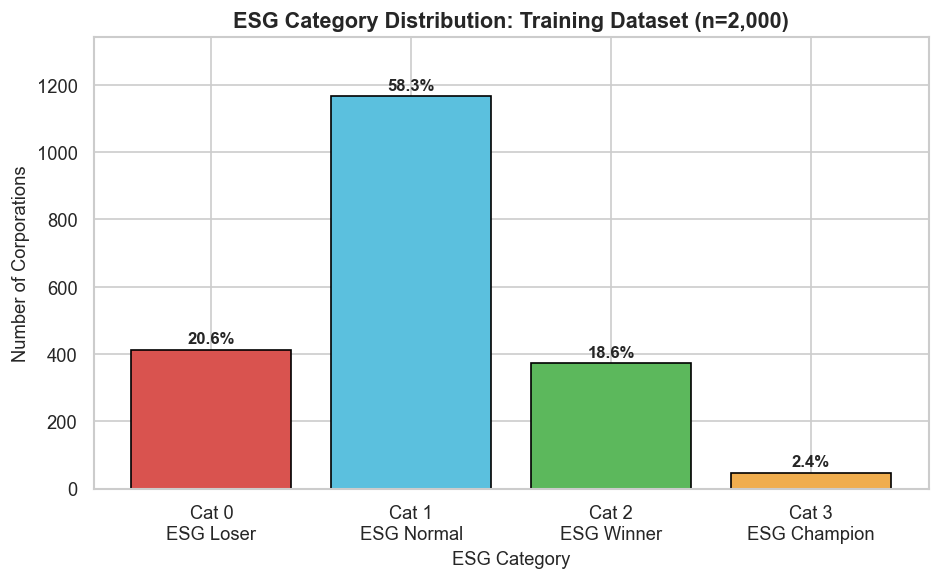

In [7]:
# bar chart showing the ESG category distribution
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    [f"Cat {c}\n{category_labels[c]}" for c in counts.index],
    counts.values,
    color=['#d9534f','#5bc0de','#5cb85c','#f0ad4e'],
    edgecolor='black'
)

for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('ESG Category Distribution: Training Dataset (n=2,000)', fontsize=13, fontweight='bold')
ax.set_xlabel('ESG Category', fontsize=11)
ax.set_ylabel('Number of Corporations', fontsize=11)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

### 1.3 Missing Values

In [8]:
# check for missing values in both datasets
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

missing_df = pd.DataFrame({
    'Training Missing': missing_train,
    'Training % Missing': (missing_train / len(train) * 100).round(2),
    'Test Missing': missing_test,
    'Test % Missing': (missing_test / len(test) * 100).round(2)
})

print("Missing value summary:")
print(missing_df[missing_df['Training Missing'] > 0])

Missing value summary:
           Training Missing  Training % Missing  Test Missing  Test % Missing
FEAT_GOV3               184              9.2000            79          7.9000


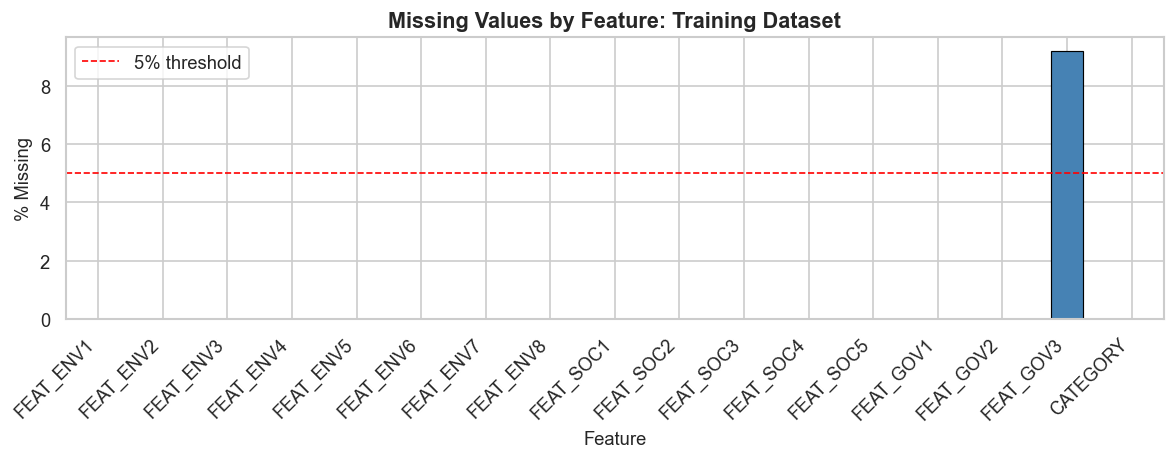

In [9]:
# bar chart showing missing values by feature
fig, ax = plt.subplots(figsize=(10, 4))

missing_pct = (train.isnull().sum() / len(train) * 100)
missing_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', linewidth=0.7)

ax.set_title('Missing Values by Feature: Training Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('% Missing', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Outlier Detection

In [10]:
# IQR outlier detection across all numerical features (Tukey method: outside Q1 - 1.5*IQR or Q3 + 1.5*IQR)
numerical_features = train.select_dtypes(include='number').columns.tolist()
numerical_features = [c for c in numerical_features if c != 'CATEGORY']

print("IQR Outlier Detection (Tukey Method):")
print()
for col in numerical_features:
    q1  = train[col].quantile(0.25)
    q3  = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outlier(s) | range [{train[col].min()}, {train[col].max()}] | bounds [{lower:.2f}, {upper:.2f}]")

print()
print("Features with no IQR outliers: all others")

IQR Outlier Detection (Tukey Method):

  FEAT_ENV3: 967 outlier(s) | range [0, 2] | bounds [1.00, 1.00]
  FEAT_GOV2: 67 outlier(s) | range [0, 1000] | bounds [-4.50, 15.50]

Features with no IQR outliers: all others


In [11]:
# Z-score outlier detection, flagging anything beyond 3 standard deviations from the mean
print("Z-Score Outlier Detection (beyond 3 SD from mean):")
print()
for col in numerical_features:
    mean = train[col].mean()
    std  = train[col].std()
    n_out = ((train[col] < mean - 3*std) | (train[col] > mean + 3*std)).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outlier(s) | mean={mean:.3f}, std={std:.3f}")

Z-Score Outlier Detection (beyond 3 SD from mean):

  FEAT_GOV2: 67 outlier(s) | mean=38.510, std=179.077


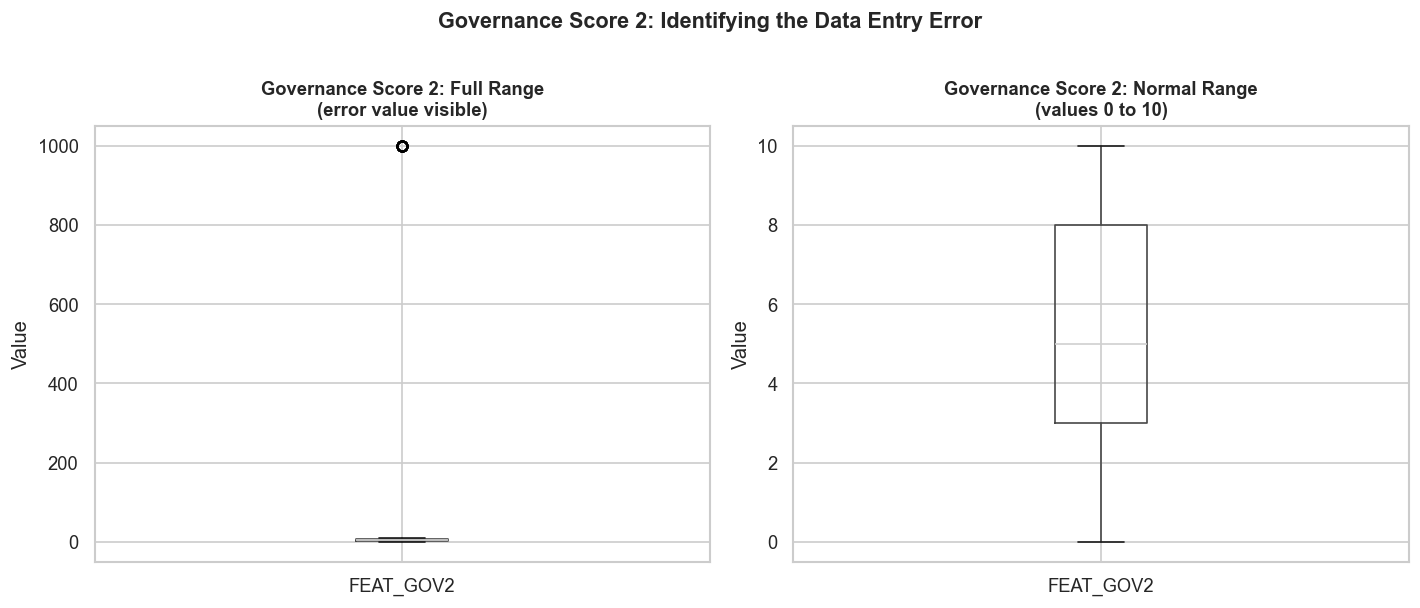

Rows where FEAT_GOV2 = 1000: 67
All other values are between 0 and 10.


In [12]:
# boxplot for FEAT_GOV2 to visualise the outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left plot shows full range so the outlier is visible
train[['FEAT_GOV2']].boxplot(ax=axes[0])
axes[0].set_title('Governance Score 2: Full Range\n(error value visible)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Value')

# right plot zoomed in to the normal 0 to 10 range
train_no_outlier = train[train['FEAT_GOV2'] <= 10]
train_no_outlier[['FEAT_GOV2']].boxplot(ax=axes[1])
axes[1].set_title('Governance Score 2: Normal Range\n(values 0 to 10)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Value')

plt.suptitle('Governance Score 2: Identifying the Data Entry Error', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

n_outlier = (train['FEAT_GOV2'] == 1000).sum()
print(f"Rows where FEAT_GOV2 = 1000: {n_outlier}")
print(f"All other values are between 0 and 10.")

### 1.5 Feature Distributions

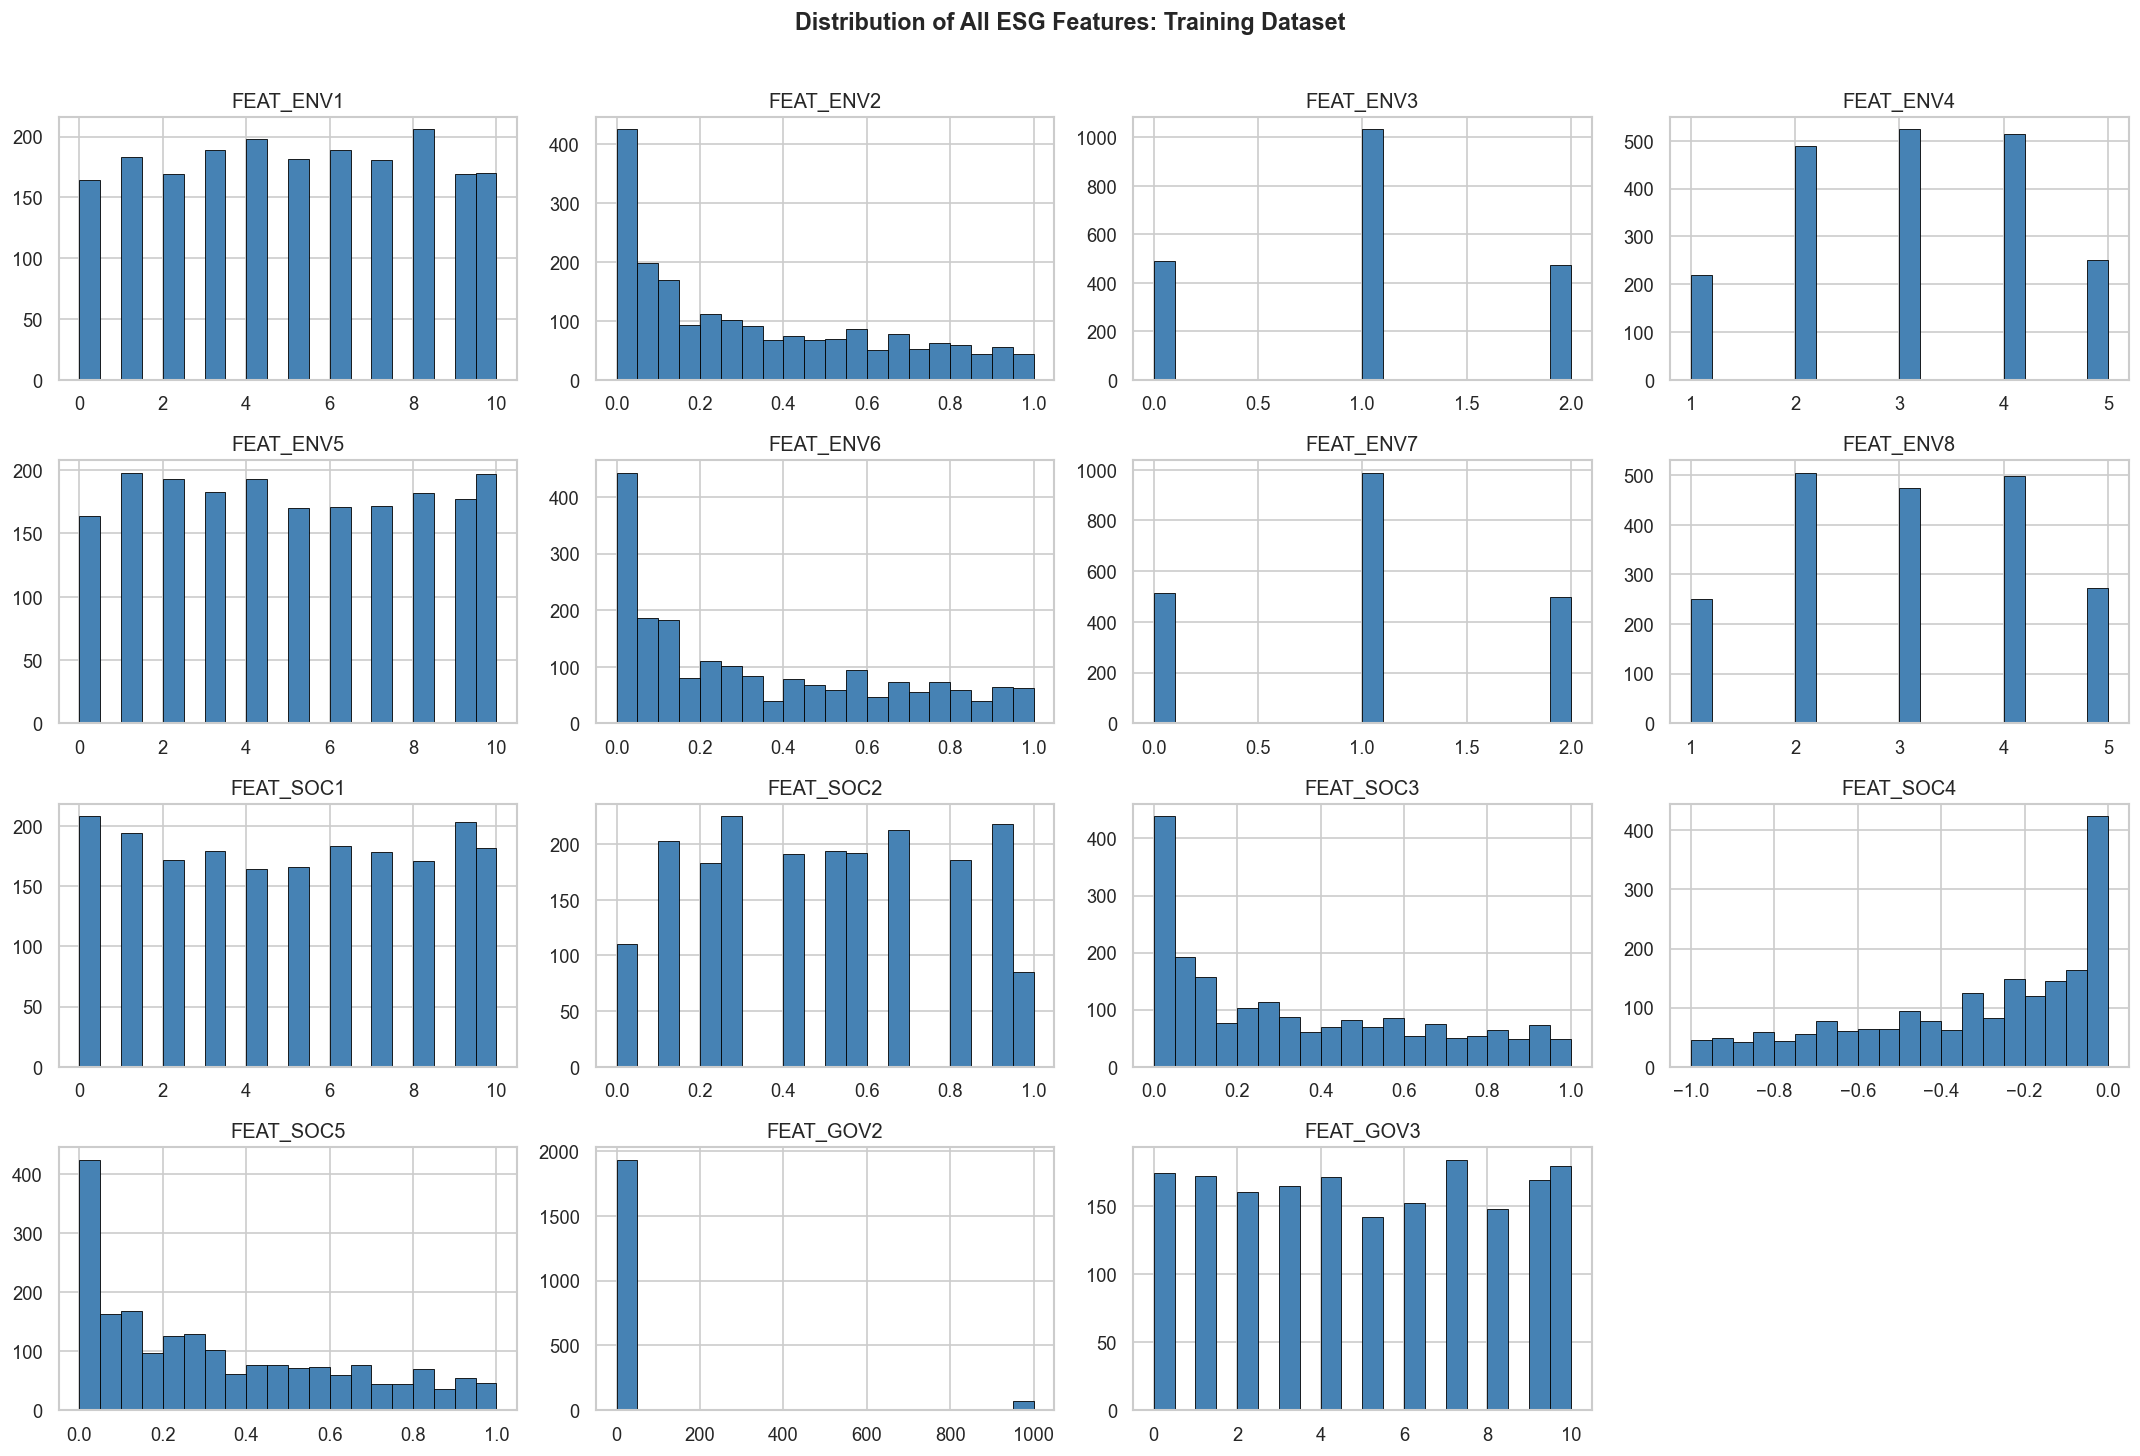

In [13]:
# histograms for all numerical features to see how each one is distributed
train[numerical_features].hist(bins=20, figsize=(18, 12), edgecolor='black', linewidth=0.5, color='steelblue')
plt.suptitle('Distribution of All ESG Features: Training Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

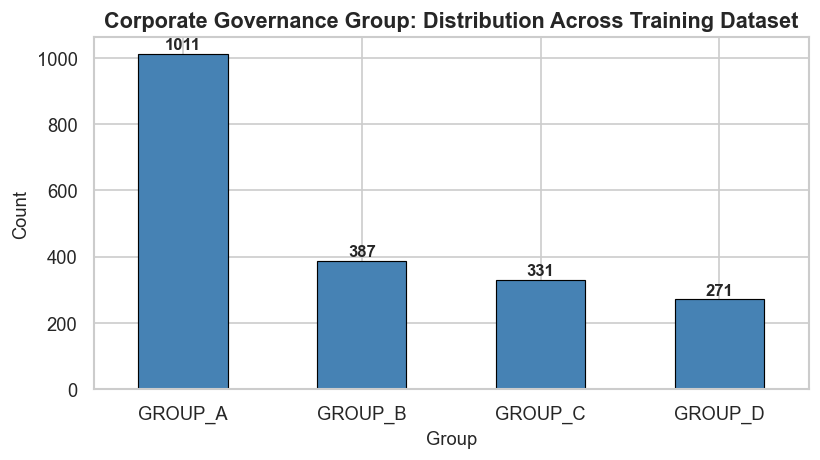

In [14]:
# bar chart showing how FEAT_GOV1 groups are distributed across the training set
gov1_counts = train['FEAT_GOV1'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
gov1_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', linewidth=0.7)

for i, v in enumerate(gov1_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Corporate Governance Group: Distribution Across Training Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Group', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 1.6 Feature Redundancy: FEAT_SOC4 and FEAT_SOC5

In [15]:
# check whether FEAT_SOC4 and FEAT_SOC5 are carrying the same information
correlation = train['FEAT_SOC4'].corr(train['FEAT_SOC5'])
print(f"Pearson correlation between FEAT_SOC4 and FEAT_SOC5: {correlation:.4f}")
print()
print("Sample values (first 10 rows):")
print(train[['FEAT_SOC4','FEAT_SOC5']].head(10).to_string())
print()
# check if FEAT_SOC4 is exactly the negative of FEAT_SOC5
is_mirror = (train['FEAT_SOC4'] + train['FEAT_SOC5']).abs().max()
print(f"Max absolute difference (FEAT_SOC4 + FEAT_SOC5): {is_mirror}")
print("FEAT_SOC4 = -FEAT_SOC5 exactly" if is_mirror == 0 else "Not an exact mirror")

Pearson correlation between FEAT_SOC4 and FEAT_SOC5: -1.0000

Sample values (first 10 rows):
   FEAT_SOC4  FEAT_SOC5
0    -0.2700     0.2700
1    -0.9500     0.9500
2    -0.2600     0.2600
3    -0.7800     0.7800
4    -0.6100     0.6100
5    -0.2200     0.2200
6    -0.1800     0.1800
7    -0.9300     0.9300
8    -0.2000     0.2000
9    -0.4100     0.4100

Max absolute difference (FEAT_SOC4 + FEAT_SOC5): 0.0
FEAT_SOC4 = -FEAT_SOC5 exactly


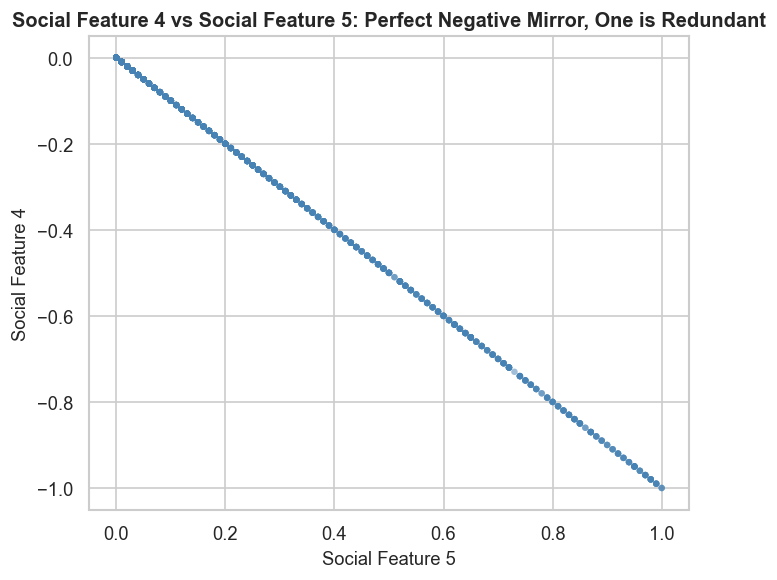

In [16]:
# scatter plot of FEAT_SOC4 vs FEAT_SOC5 to make the mirror relationship obvious
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(train['FEAT_SOC5'], train['FEAT_SOC4'], alpha=0.3, color='steelblue', edgecolor='none', s=15)
ax.set_title('Social Feature 4 vs Social Feature 5: Perfect Negative Mirror, One is Redundant', fontsize=12, fontweight='bold')
ax.set_xlabel('Social Feature 5', fontsize=11)
ax.set_ylabel('Social Feature 4', fontsize=11)
plt.tight_layout()
plt.show()

### 1.7 Correlation Analysis

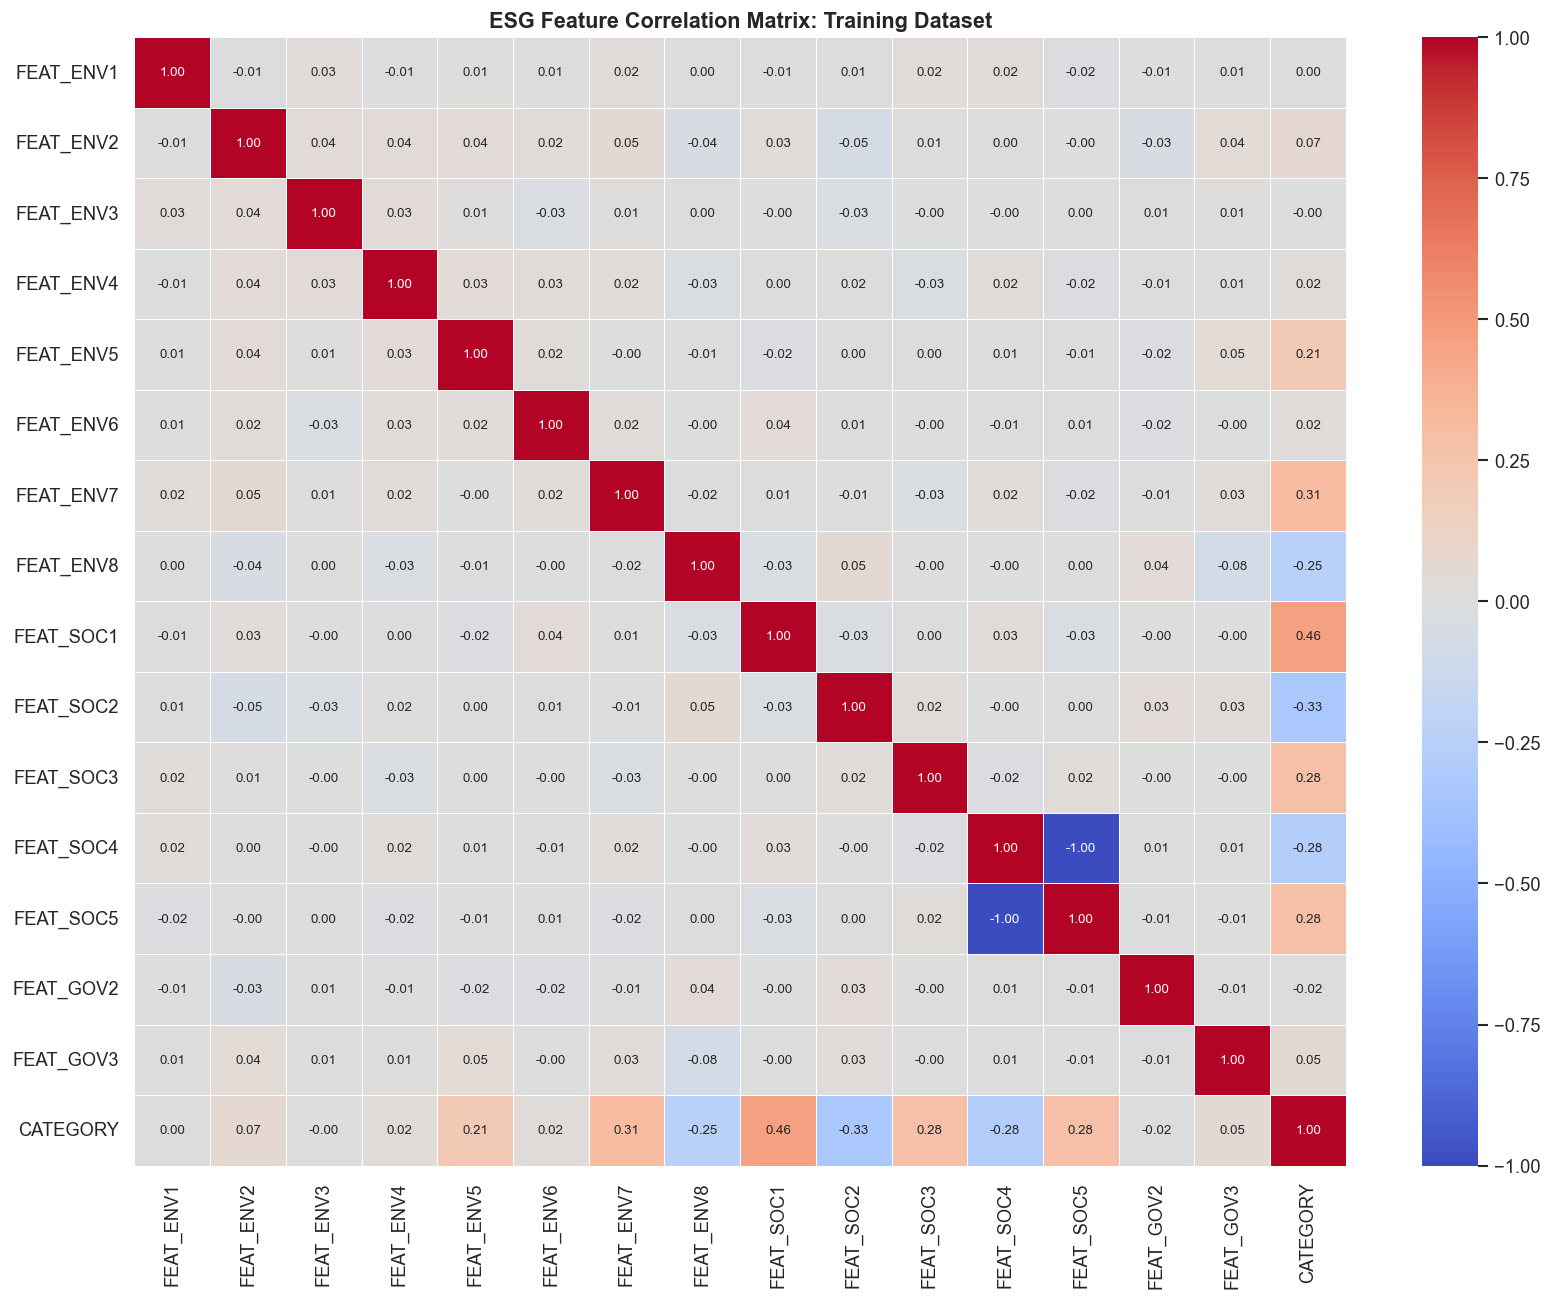

In [17]:
# correlation heatmap across all numerical features including the target
corr_matrix = train[numerical_features + ['CATEGORY']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('ESG Feature Correlation Matrix: Training Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# rank features by how strongly they correlate with the ESG target
# compute absolute correlations first, sort, then map back to signed values for display
target_corr_abs = corr_matrix['CATEGORY'].drop('CATEGORY').abs().sort_values(ascending=False)
target_corr     = corr_matrix['CATEGORY'].drop('CATEGORY').reindex(target_corr_abs.index)

print("Correlation with CATEGORY (ranked by strength):")
for feat, val in target_corr.items():
    bar = 'X' * int(abs(val) * 30)
    direction = '+' if val > 0 else '-'
    print(f"  {feat:<12}  {direction}{abs(val):.4f}  {bar}")

Correlation with CATEGORY (ranked by strength):
  FEAT_SOC1     +0.4614  XXXXXXXXXXXXX
  FEAT_SOC2     -0.3253  XXXXXXXXX
  FEAT_ENV7     +0.3113  XXXXXXXXX
  FEAT_SOC3     +0.2755  XXXXXXXX
  FEAT_SOC4     -0.2754  XXXXXXXX
  FEAT_SOC5     +0.2754  XXXXXXXX
  FEAT_ENV8     -0.2487  XXXXXXX
  FEAT_ENV5     +0.2133  XXXXXX
  FEAT_ENV2     +0.0664  X
  FEAT_GOV3     +0.0477  X
  FEAT_ENV6     +0.0207  
  FEAT_ENV4     +0.0170  
  FEAT_GOV2     -0.0153  
  FEAT_ENV1     +0.0049  
  FEAT_ENV3     -0.0036  


### 1.8 Feature-Target Relationships

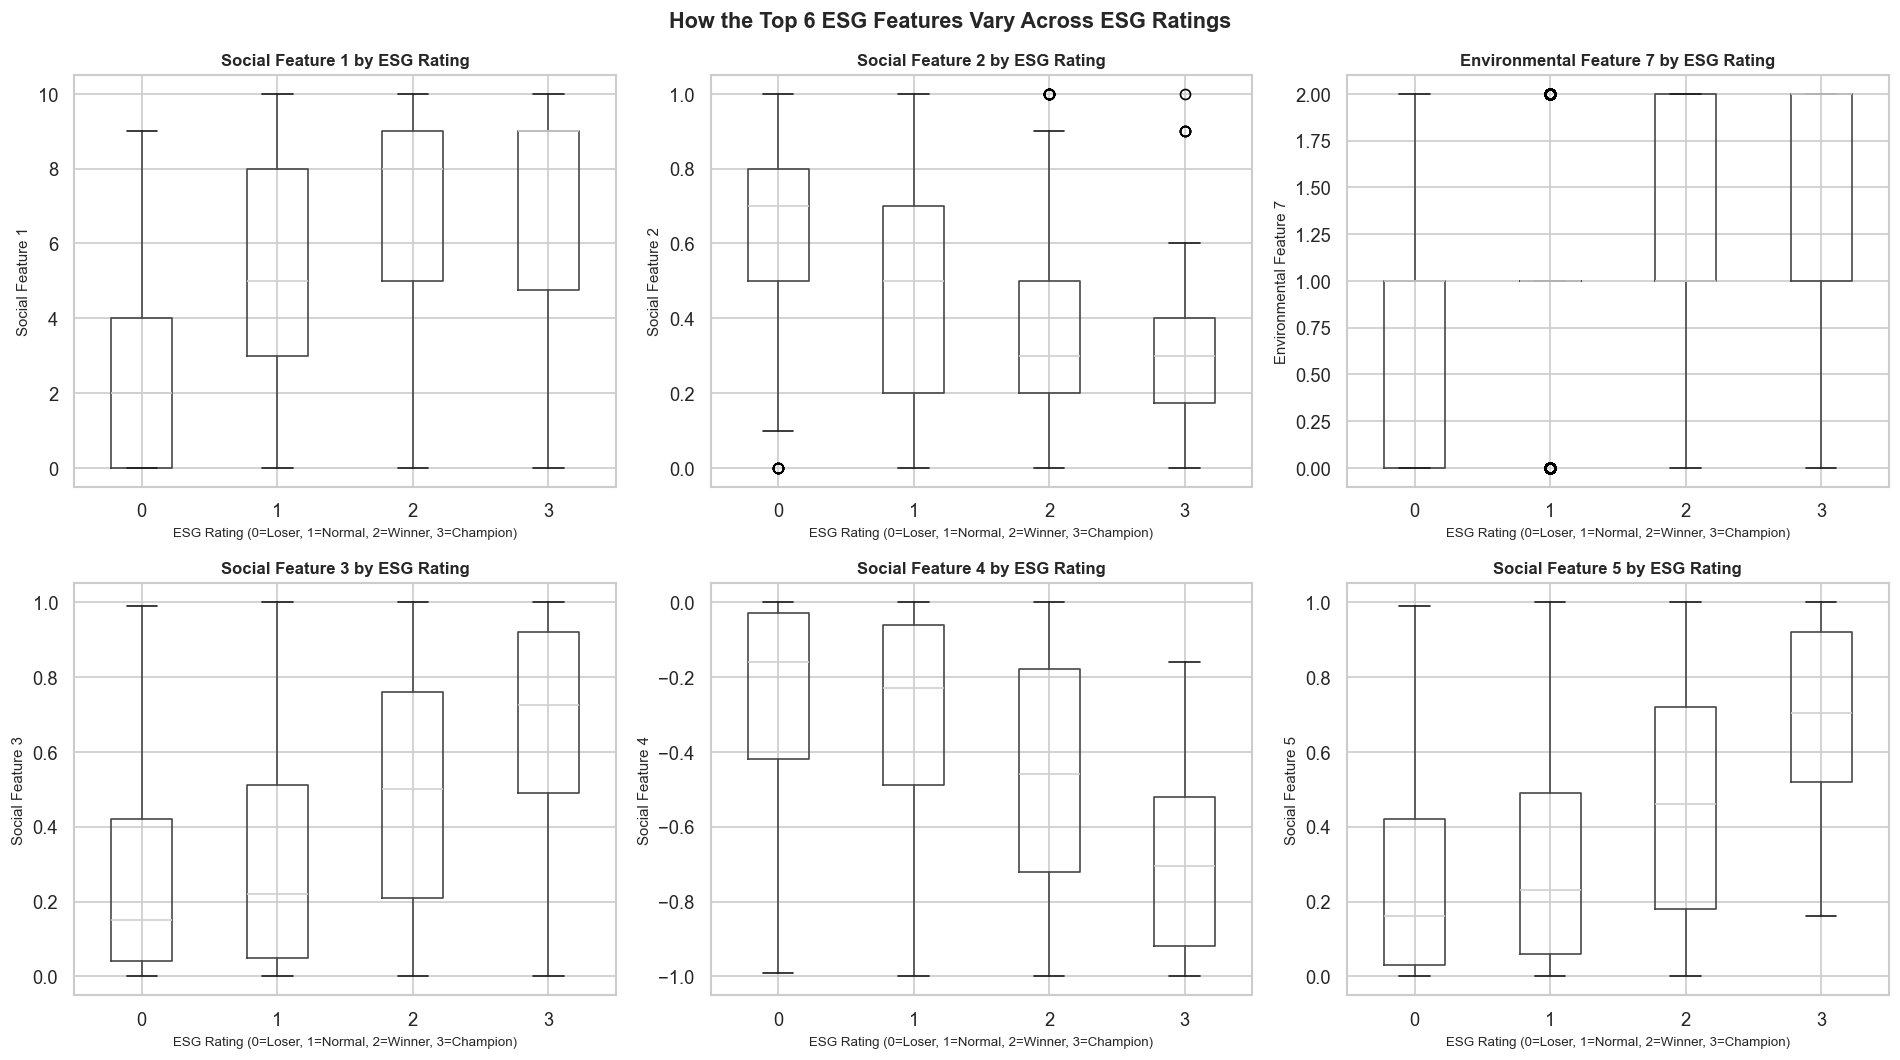

In [19]:
# grouped boxplots for the top 6 features split by ESG category
top_features = target_corr_abs.head(6).index.tolist()

# human-readable labels so chart titles avoid raw feature codes
feat_name_map = {
    'FEAT_ENV1': 'Environmental Feature 1',
    'FEAT_ENV2': 'Environmental Feature 2',
    'FEAT_ENV3': 'Environmental Feature 3',
    'FEAT_ENV4': 'Environmental Feature 4',
    'FEAT_ENV5': 'Environmental Feature 5',
    'FEAT_ENV6': 'Environmental Feature 6',
    'FEAT_ENV7': 'Environmental Feature 7',
    'FEAT_ENV8': 'Environmental Feature 8',
    'FEAT_SOC1': 'Social Feature 1',
    'FEAT_SOC2': 'Social Feature 2',
    'FEAT_SOC3': 'Social Feature 3',
    'FEAT_SOC4': 'Social Feature 4',
    'FEAT_SOC5': 'Social Feature 5',
    'FEAT_GOV1': 'Governance Group',
    'FEAT_GOV2': 'Governance Score 2',
    'FEAT_GOV3': 'Governance Score 3',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_label = feat_name_map.get(feat, feat)
    train.boxplot(column=feat, by='CATEGORY', ax=axes[i])
    axes[i].set_title(f'{feat_label} by ESG Rating', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('ESG Rating (0=Loser, 1=Normal, 2=Winner, 3=Champion)', fontsize=8)
    axes[i].set_ylabel(feat_label, fontsize=9)

plt.suptitle('How the Top 6 ESG Features Vary Across ESG Ratings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

FEAT_GOV1 vs CATEGORY: row percentages
CATEGORY        0       1       2      3
FEAT_GOV1                               
GROUP_A   21.4000 57.6000 18.6000 2.5000
GROUP_B   20.7000 58.7000 18.3000 2.3000
GROUP_C   19.9000 58.0000 19.0000 3.0000
GROUP_D   18.8000 60.9000 18.8000 1.5000



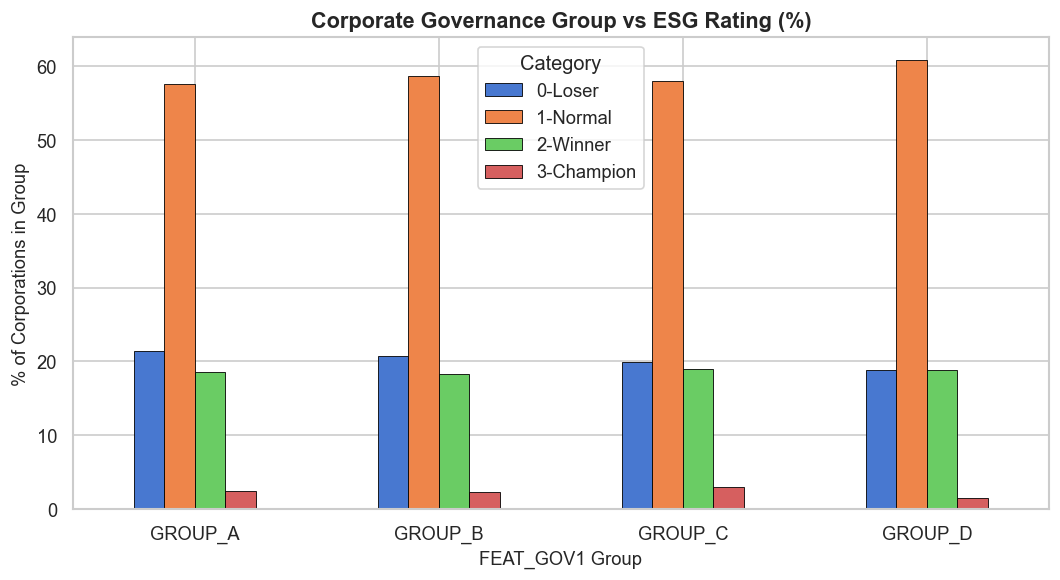

In [20]:
# look at how FEAT_GOV1 groups break down across ESG categories
gov1_cat     = train.groupby(['FEAT_GOV1', 'CATEGORY']).size().unstack(fill_value=0)
gov1_cat_pct = gov1_cat.div(gov1_cat.sum(axis=1), axis=0) * 100

print("FEAT_GOV1 vs CATEGORY: row percentages")
print(gov1_cat_pct.round(1))
print()

fig, ax = plt.subplots(figsize=(9, 5))
gov1_cat_pct.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Corporate Governance Group vs ESG Rating (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('FEAT_GOV1 Group', fontsize=11)
ax.set_ylabel('% of Corporations in Group', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Category', labels=['0-Loser', '1-Normal', '2-Winner', '3-Champion'])
plt.tight_layout()
plt.show()

---
## Section 2: Machine Learning Model Development and Evaluation
> *Building and comparing classification models to recommend one for deployment.*

### 2.1 Data Preprocessing

In [21]:
# make copies so we don't change the original data from Section 1
train_clean = train.copy()
test_clean  = test.copy()

# Step 1: drop FEAT_SOC4 since it is a perfect mirror of FEAT_SOC5 and adds nothing to the model
train_clean.drop(columns=['FEAT_SOC4'], inplace=True)
test_clean.drop(columns=['FEAT_SOC4'], inplace=True)

print("Step 1 complete: FEAT_SOC4 dropped")
print(f"  Training shape: {train_clean.shape}")
print(f"  Test shape    : {test_clean.shape}")

Step 1 complete: FEAT_SOC4 dropped
  Training shape: (2000, 16)
  Test shape    : (1000, 16)


In [22]:
# Step 2: fix the FEAT_GOV2 outlier by replacing the value 1000 with the median of normal values
gov2_median = train_clean[train_clean['FEAT_GOV2'] <= 10]['FEAT_GOV2'].median()

train_clean.loc[train_clean['FEAT_GOV2'] > 10, 'FEAT_GOV2'] = gov2_median
test_clean.loc[test_clean['FEAT_GOV2'] > 10, 'FEAT_GOV2'] = gov2_median

print(f"Step 2 complete: FEAT_GOV2 outlier replaced with median = {gov2_median}")
print(f"  FEAT_GOV2 range in training: {train_clean['FEAT_GOV2'].min()} to {train_clean['FEAT_GOV2'].max()}")

Step 2 complete: FEAT_GOV2 outlier replaced with median = 5.0
  FEAT_GOV2 range in training: 0 to 10


In [23]:
# Step 3: Impute FEAT_GOV3 missing values with the median (training median applied to both)
gov3_median = train_clean['FEAT_GOV3'].median()

# Direct assignment — more reliable than inplace=True in pandas 2.0+
train_clean['FEAT_GOV3'] = train_clean['FEAT_GOV3'].fillna(gov3_median)
test_clean['FEAT_GOV3']  = test_clean['FEAT_GOV3'].fillna(gov3_median)

print(f"Step 3 complete: FEAT_GOV3 missing values filled with median = {gov3_median}")
print(f"  Remaining missing in training: {train_clean['FEAT_GOV3'].isnull().sum()}")
print(f"  Remaining missing in test    : {test_clean['FEAT_GOV3'].isnull().sum()}")

# Safety check — confirm no NaN anywhere before modelling
total_missing = train_clean.isnull().sum().sum()
print(f"  Total NaN remaining in train_clean: {total_missing} ({'✅ Clean' if total_missing == 0 else '❌ Still has NaN'})")

Step 3 complete: FEAT_GOV3 missing values filled with median = 5.0
  Remaining missing in training: 0
  Remaining missing in test    : 0
  Total NaN remaining in train_clean: 0 (✅ Clean)


### 2.2 Feature Encoding and Scaling

In [24]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 4: label encode FEAT_GOV1 so the model can read it (GROUP_A/B/C/D gets mapped to 0/1/2/3)
# we fit on training data only then apply to both
le = LabelEncoder()
train_clean['FEAT_GOV1'] = le.fit_transform(train_clean['FEAT_GOV1'])
test_clean['FEAT_GOV1']  = le.transform(test_clean['FEAT_GOV1'])

print("Step 4 complete: FEAT_GOV1 label encoded")
print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Step 4 complete: FEAT_GOV1 label encoded
  Mapping: {'GROUP_A': np.int64(0), 'GROUP_B': np.int64(1), 'GROUP_C': np.int64(2), 'GROUP_D': np.int64(3)}


In [25]:
# Step 5: separate features and target for both datasets
feature_cols = [c for c in train_clean.columns if c != 'CATEGORY']

X_train = train_clean[feature_cols].copy()
y_train = train_clean['CATEGORY'].copy()

X_test  = test_clean[feature_cols].copy()
y_test  = test_clean['CATEGORY'].copy()

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

Features used (15): ['FEAT_ENV1', 'FEAT_ENV2', 'FEAT_ENV3', 'FEAT_ENV4', 'FEAT_ENV5', 'FEAT_ENV6', 'FEAT_ENV7', 'FEAT_ENV8', 'FEAT_SOC1', 'FEAT_SOC2', 'FEAT_SOC3', 'FEAT_SOC5', 'FEAT_GOV1', 'FEAT_GOV2', 'FEAT_GOV3']
X_train shape: (2000, 15)
X_test shape : (1000, 15)


In [26]:
# Step 6: scale the features using StandardScaler, fitting on training data only then applying to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Step 6 complete: StandardScaler applied")
print(f"  X_train_scaled mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"  X_train_scaled std  (should be ~1): {X_train_scaled.std():.6f}")

Step 6 complete: StandardScaler applied
  X_train_scaled mean (should be ~0): -0.000000
  X_train_scaled std  (should be ~1): 1.000000


### 2.3 Handling Class Imbalance

In [27]:
# class distribution before we handle the imbalance
print("Class distribution BEFORE oversampling:")
for cat, cnt in y_train.value_counts().sort_index().items():
    pct = cnt / len(y_train) * 100
    print(f"  Category {cat}: {cnt:>5} rows ({pct:.1f}%)")

Class distribution BEFORE oversampling:
  Category 0:   413 rows (20.6%)
  Category 1:  1166 rows (58.3%)
  Category 2:   373 rows (18.6%)
  Category 3:    48 rows (2.4%)


In [28]:
# oversample Category 3 (ESG Champion) by duplicating its rows to reduce the imbalance
# this is only applied to training data, the test set stays untouched
# using pd.concat to duplicate the minority class rows as shown in Lecture 10

# rebuild a combined dataframe with features and target together so we can filter by class
train_preprocessed = X_train.copy()
train_preprocessed['CATEGORY'] = y_train.values

# isolate Category 3 rows then duplicate them 7 times (48 x 7 = 336, total becomes 384)
cat3_rows        = train_preprocessed[train_preprocessed['CATEGORY'] == 3]
cat3_oversampled = pd.concat([cat3_rows] * 7, ignore_index=True)
train_balanced   = pd.concat([train_preprocessed, cat3_oversampled], ignore_index=True)

# shuffle so the duplicated rows are not all clumped at the end
np.random.seed(42)
shuffled_idx   = np.random.permutation(len(train_balanced))
train_balanced = train_balanced.iloc[shuffled_idx].reset_index(drop=True)

# separate back into X and y
X_train_bal = train_balanced[feature_cols].values
y_train_bal = train_balanced['CATEGORY'].values.astype(int)

# re-scale using the same scaler already fitted on X_train
X_train_bal_scaled = scaler.transform(X_train_bal)

print("Oversampling complete (Category 3 duplicated x7):")
for cat in sorted(set(y_train_bal)):
    cnt = (y_train_bal == cat).sum()
    pct = cnt / len(y_train_bal) * 100
    print(f"  Category {cat}: {cnt:>5} rows ({pct:.1f}%)")
print(f"  Total training rows after oversampling: {len(y_train_bal)}")

Oversampling complete (Category 3 duplicated x7):
  Category 0:   413 rows (17.7%)
  Category 1:  1166 rows (49.9%)
  Category 2:   373 rows (16.0%)
  Category 3:   384 rows (16.4%)
  Total training rows after oversampling: 2336


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


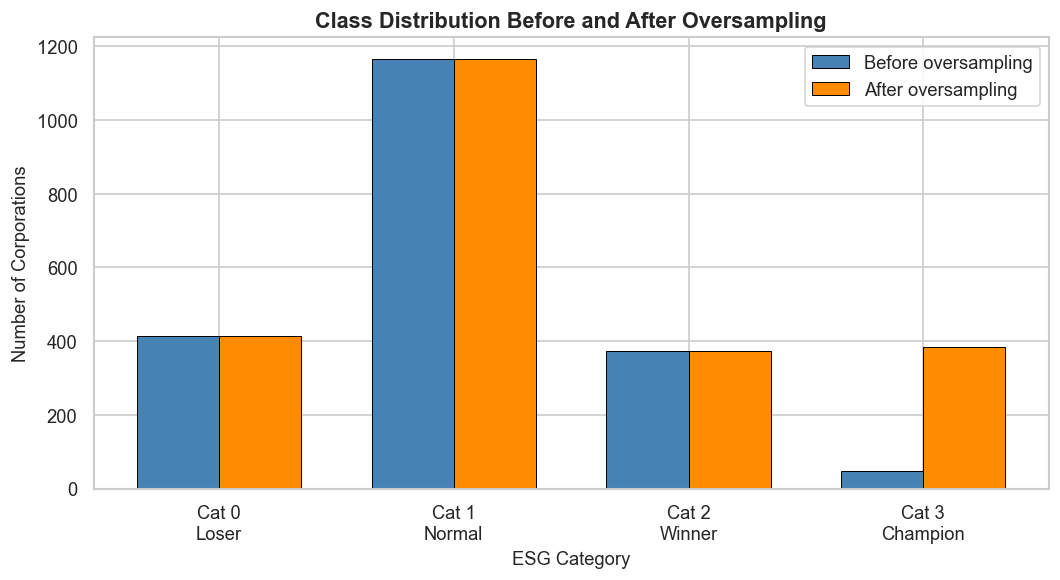

In [29]:
# bar chart comparing class distribution before and after oversampling
before = y_train.value_counts().sort_index()
after  = {cat: (y_train_bal == cat).sum() for cat in sorted(set(y_train_bal))}

x      = np.arange(4)
width  = 0.35
labels = ['Cat 0\nLoser', 'Cat 1\nNormal', 'Cat 2\nWinner', 'Cat 3\nChampion']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, before.values, width, label='Before oversampling', color='steelblue', edgecolor='black', linewidth=0.6)
ax.bar(x + width/2, [after[c] for c in range(4)], width, label='After oversampling', color='darkorange', edgecolor='black', linewidth=0.6)

ax.set_title('Class Distribution Before and After Oversampling', fontsize=13, fontweight='bold')
ax.set_xlabel('ESG Category', fontsize=11)
ax.set_ylabel('Number of Corporations', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Model Training

In [30]:
from sklearn.linear_model import LogisticRegression

# train Logistic Regression
# lbfgs handles multi-class natively and max_iter is raised to make sure it converges
lr = LogisticRegression(solver='lbfgs', max_iter=10000, random_state=42)
lr.fit(X_train_bal_scaled, y_train_bal)

print("Logistic Regression trained ✅")

Logistic Regression trained ✅


In [31]:
from sklearn.ensemble import RandomForestClassifier

# train Random Forest
# 100 trees gives a good balance between stability and computation time
rf = RandomForestClassifier(n_estimators=100, random_state=22)
rf.fit(X_train_bal_scaled, y_train_bal)

print("Random Forest trained ✅")

Random Forest trained ✅


### 2.5 Hyperparameter Sensitivity Check

In [32]:
# quick sensitivity check so our parameter choices are justified rather than just assumed
# we vary one setting at a time and compare test accuracy, keeping everything else fixed
from sklearn.metrics import accuracy_score

print("Logistic Regression: regularisation strength C")
for c in [0.01, 0.1, 1.0, 10.0]:
    m = LogisticRegression(solver='lbfgs', max_iter=10000, C=c, random_state=42)
    m.fit(X_train_bal_scaled, y_train_bal)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f"  C = {c:<6}: test accuracy {acc:.4f}")

print()
print("Random Forest: number of trees")
for n in [50, 100, 200, 300]:
    m = RandomForestClassifier(n_estimators=n, random_state=22)
    m.fit(X_train_bal_scaled, y_train_bal)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f"  n_estimators = {n:<4}: test accuracy {acc:.4f}")

Logistic Regression: regularisation strength C
  C = 0.01  : test accuracy 0.7050
  C = 0.1   : test accuracy 0.7800
  C = 1.0   : test accuracy 0.7860
  C = 10.0  : test accuracy 0.7880

Random Forest: number of trees
  n_estimators = 50  : test accuracy 0.7960


  n_estimators = 100 : test accuracy 0.8040


  n_estimators = 200 : test accuracy 0.8130


  n_estimators = 300 : test accuracy 0.8090


### 2.5 Model Evaluation

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score

# generate predictions for both models on both the training and test sets
lr_pred_train = lr.predict(X_train_bal_scaled)
lr_pred_test  = lr.predict(X_test_scaled)

rf_pred_train = rf.predict(X_train_bal_scaled)
rf_pred_test  = rf.predict(X_test_scaled)

# accuracy scores
lr_acc_train = accuracy_score(y_train_bal, lr_pred_train)
lr_acc_test  = accuracy_score(y_test,      lr_pred_test)

rf_acc_train = accuracy_score(y_train_bal, rf_pred_train)
rf_acc_test  = accuracy_score(y_test,      rf_pred_test)

print("=" * 45)
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10}")
print("=" * 45)
print(f"{'Logistic Regression':<22} {lr_acc_train:>10.4f} {lr_acc_test:>10.4f}")
print(f"{'Random Forest':<22} {rf_acc_train:>10.4f} {rf_acc_test:>10.4f}")
print("=" * 45)

Model                   Train Acc   Test Acc
Logistic Regression        0.8228     0.7860
Random Forest              1.0000     0.8040


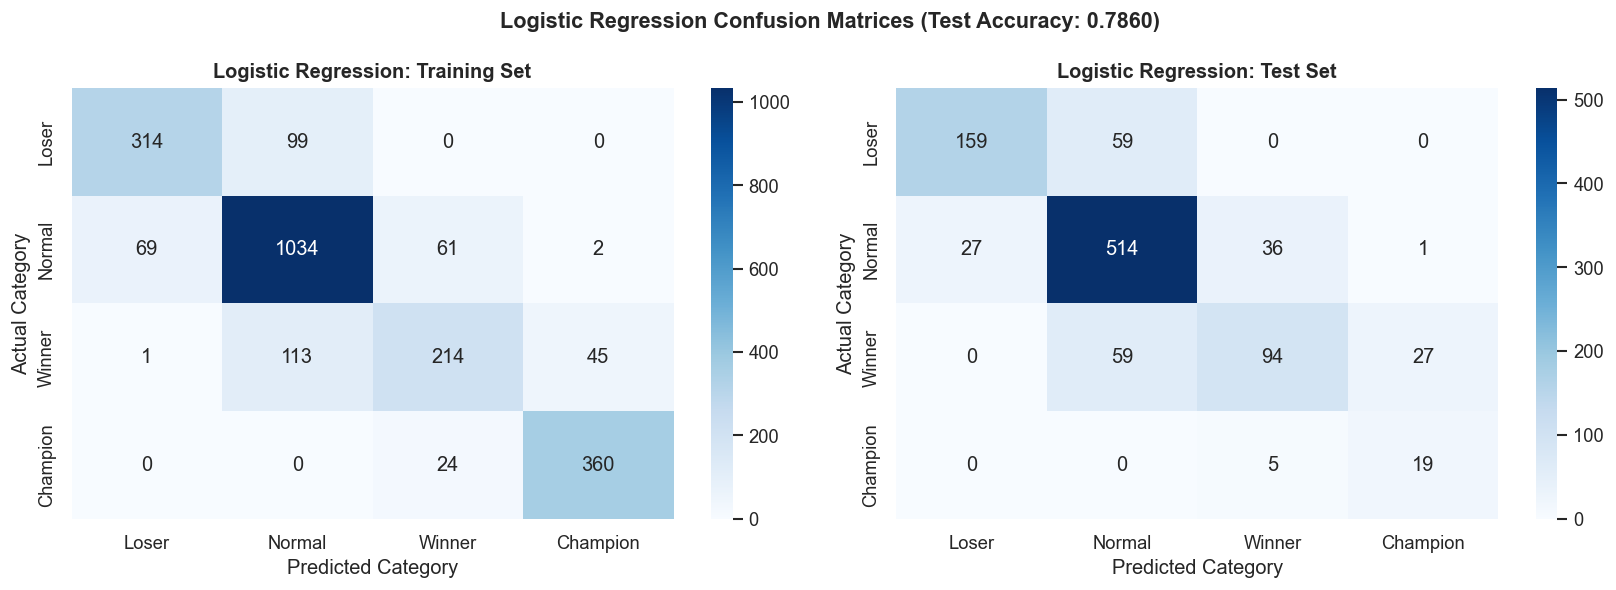

In [34]:
# confusion matrices for Logistic Regression on training and test sets
cat_labels = [0, 1, 2, 3]
cat_names  = ['Loser', 'Normal', 'Winner', 'Champion']

cm_lr_train = confusion_matrix(y_train_bal, lr_pred_train, labels=cat_labels)
cm_lr_test  = confusion_matrix(y_test,      lr_pred_test,  labels=cat_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lr_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_names, yticklabels=cat_names, ax=axes[0])
axes[0].set_title('Logistic Regression: Training Set', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Category')
axes[0].set_ylabel('Actual Category')

sns.heatmap(cm_lr_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_names, yticklabels=cat_names, ax=axes[1])
axes[1].set_title('Logistic Regression: Test Set', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Category')
axes[1].set_ylabel('Actual Category')

plt.suptitle(f'Logistic Regression Confusion Matrices (Test Accuracy: {lr_acc_test:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

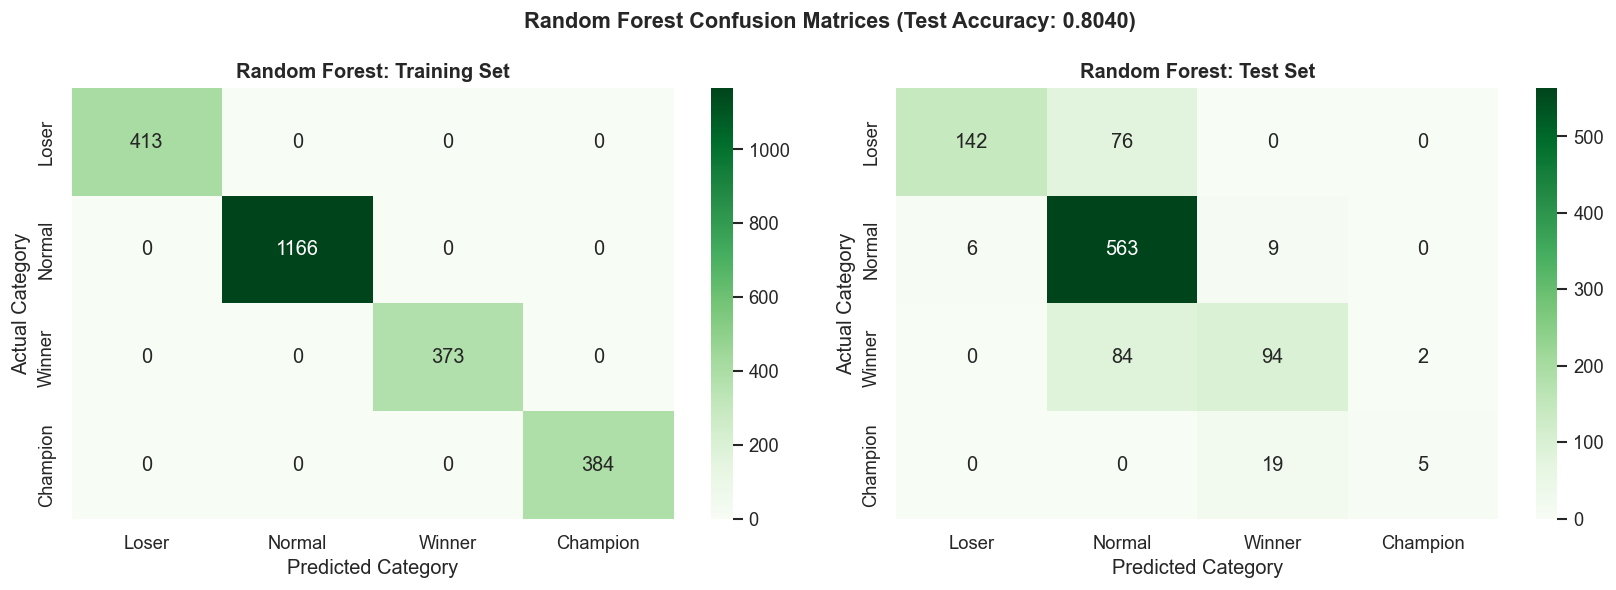

In [35]:
# confusion matrices for Random Forest on training and test sets
cm_rf_train = confusion_matrix(y_train_bal, rf_pred_train, labels=cat_labels)
cm_rf_test  = confusion_matrix(y_test,      rf_pred_test,  labels=cat_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=cat_names, yticklabels=cat_names, ax=axes[0])
axes[0].set_title('Random Forest: Training Set', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Category')
axes[0].set_ylabel('Actual Category')

sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=cat_names, yticklabels=cat_names, ax=axes[1])
axes[1].set_title('Random Forest: Test Set', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Category')
axes[1].set_ylabel('Actual Category')

plt.suptitle(f'Random Forest Confusion Matrices (Test Accuracy: {rf_acc_test:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 ROC Curves and Class Separability

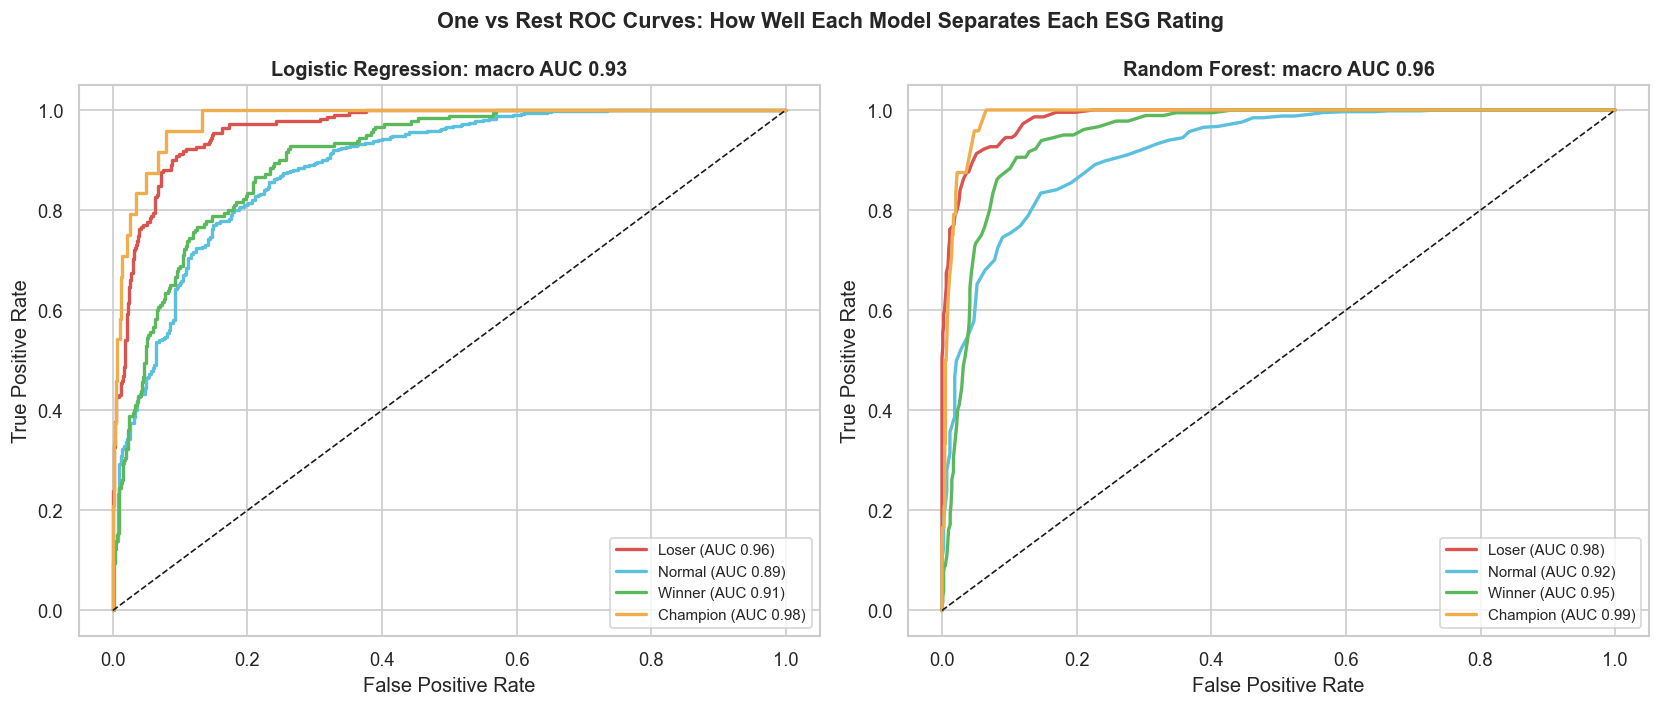

Logistic Regression: Loser 0.964, Normal 0.890, Winner 0.906, Champion 0.980 | macro AUC 0.935
Random Forest: Loser 0.984, Normal 0.920, Winner 0.950, Champion 0.987 | macro AUC 0.960


In [36]:
# ROC curves and AUC, one class versus the rest, as named in the assignment brief
# this looks at how well each model separates each ESG rating across all probability thresholds
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = [0, 1, 2, 3]
y_test_bin = label_binarize(y_test, classes=classes)

# predicted class probabilities from each model
lr_proba = lr.predict_proba(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)

names  = ['Loser', 'Normal', 'Winner', 'Champion']
colors = ['#d9534f', '#5bc0de', '#5cb85c', '#f0ad4e']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proba, title in [(axes[0], lr_proba, 'Logistic Regression'),
                         (axes[1], rf_proba, 'Random Forest')]:
    class_aucs = []
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        a = auc(fpr, tpr)
        class_aucs.append(a)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{names[i]} (AUC {a:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'{title}: macro AUC {np.mean(class_aucs):.2f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('One vs Rest ROC Curves: How Well Each Model Separates Each ESG Rating',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# print the AUC values so they can be quoted exactly
for proba, label in [(lr_proba, 'Logistic Regression'), (rf_proba, 'Random Forest')]:
    aucs = []
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        aucs.append(auc(fpr, tpr))
    summary = ", ".join(f"{names[i]} {aucs[i]:.3f}" for i in range(4))
    print(f"{label}: {summary} | macro AUC {np.mean(aucs):.3f}")

### 2.6 Error Analysis: Per-Class Performance

In [37]:
# per-class accuracy from the test confusion matrices
# diagonal entries are the correct predictions for each class
# row sums give the total actual instances per class

print("Per-Class Accuracy on TEST SET")
print("=" * 55)
print(f"{'Category':<20} {'LR Accuracy':>14} {'RF Accuracy':>14}")
print("=" * 55)

for i, (label, name) in enumerate(zip(cat_labels, cat_names)):
    lr_class_acc = cm_lr_test[i, i] / cm_lr_test[i, :].sum() if cm_lr_test[i, :].sum() > 0 else 0
    rf_class_acc = cm_rf_test[i, i] / cm_rf_test[i, :].sum() if cm_rf_test[i, :].sum() > 0 else 0
    print(f"  Cat {label} -- {name:<14} {lr_class_acc:>13.4f} {rf_class_acc:>14.4f}")

print("=" * 55)
print(f"  {'Overall':<19} {lr_acc_test:>14.4f} {rf_acc_test:>14.4f}")

Per-Class Accuracy on TEST SET
Category                LR Accuracy    RF Accuracy
  Cat 0 -- Loser                 0.7294         0.6514
  Cat 1 -- Normal                0.8893         0.9740
  Cat 2 -- Winner                0.5222         0.5222
  Cat 3 -- Champion              0.7917         0.2083
  Overall                     0.7860         0.8040


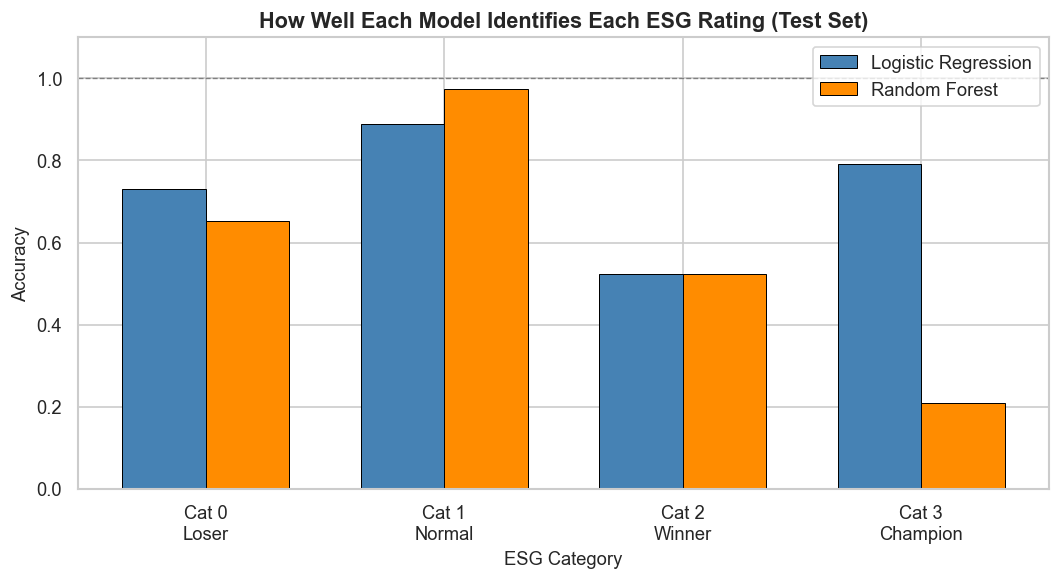

In [38]:
# bar chart comparing per-class accuracy for both models on the test set
lr_class_accs = []
rf_class_accs = []

for i in range(4):
    lr_class_accs.append(cm_lr_test[i, i] / cm_lr_test[i, :].sum() if cm_lr_test[i, :].sum() > 0 else 0)
    rf_class_accs.append(cm_rf_test[i, i] / cm_rf_test[i, :].sum() if cm_rf_test[i, :].sum() > 0 else 0)

x      = np.arange(4)
width  = 0.35
labels = ['Cat 0\nLoser', 'Cat 1\nNormal', 'Cat 2\nWinner', 'Cat 3\nChampion']

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lr_class_accs, width, label='Logistic Regression', color='steelblue',  edgecolor='black', linewidth=0.6)
ax.bar(x + width/2, rf_class_accs, width, label='Random Forest',       color='darkorange', edgecolor='black', linewidth=0.6)

ax.set_title('How Well Each Model Identifies Each ESG Rating (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('ESG Category', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

### 2.7 Feature Importances (Random Forest)

In [39]:
# extract feature importances from the Random Forest and rank them
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importances (Random Forest):")
print(importance_df.to_string(index=False))

Feature Importances (Random Forest):
  Feature  Importance
FEAT_SOC1      0.1475
FEAT_SOC5      0.1323
FEAT_SOC3      0.1250
FEAT_ENV8      0.0904
FEAT_SOC2      0.0903
FEAT_ENV7      0.0633
FEAT_ENV5      0.0605
FEAT_ENV6      0.0552
FEAT_ENV2      0.0537
FEAT_GOV2      0.0410
FEAT_ENV1      0.0379
FEAT_GOV3      0.0377
FEAT_ENV4      0.0268
FEAT_GOV1      0.0210
FEAT_ENV3      0.0174


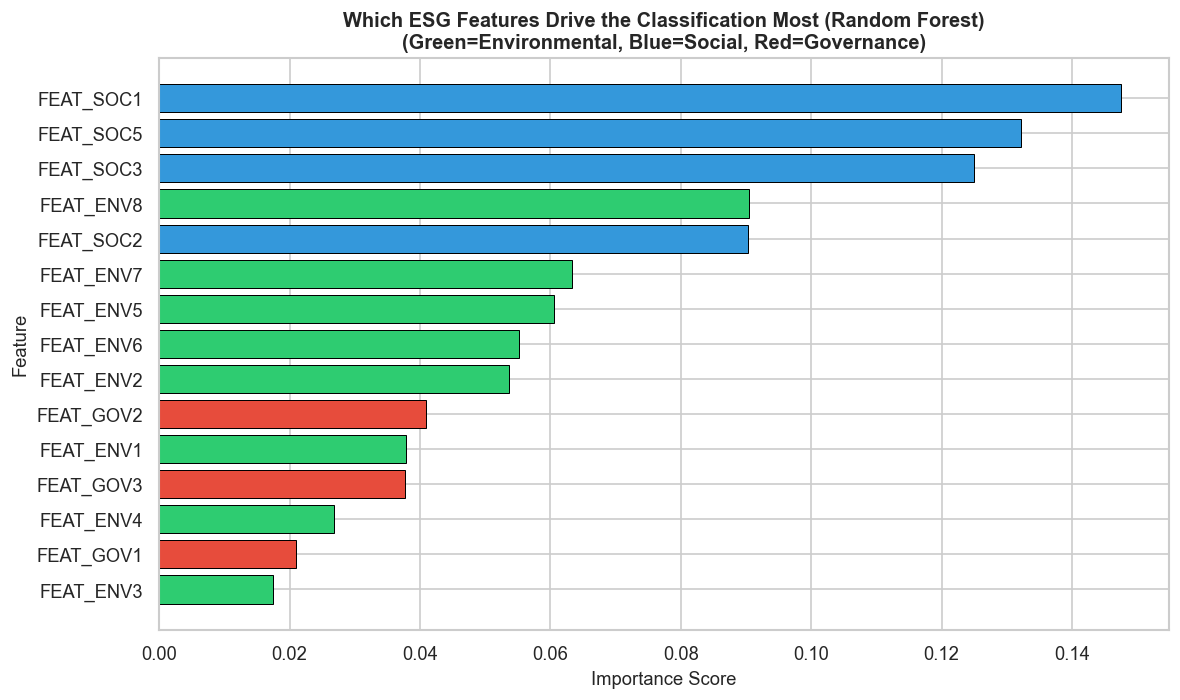

In [40]:
# horizontal bar chart showing feature importances, colour coded by feature group
# green = Environmental, blue = Social, red = Governance
colours = ['#2ecc71' if f.startswith('FEAT_ENV') else
           '#3498db' if f.startswith('FEAT_SOC') else
           '#e74c3c' for f in importance_df['Feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
        color=colours[::-1], edgecolor='black', linewidth=0.6)

ax.set_title('Which ESG Features Drive the Classification Most (Random Forest)\n(Green=Environmental, Blue=Social, Red=Governance)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

### 2.8 Model Comparison Summary

In [41]:
# summary table comparing both models across accuracy, overfitting, and governance suitability
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<35} {'Log. Reg.':>10} {'Rand. Forest':>12}")
print("-" * 60)
print(f"{'Training Accuracy':<35} {lr_acc_train:>10.4f} {rf_acc_train:>12.4f}")
print(f"{'Test Accuracy':<35} {lr_acc_test:>10.4f} {rf_acc_test:>12.4f}")
print(f"{'Overfitting Gap (Train - Test)':<35} {lr_acc_train - lr_acc_test:>10.4f} {rf_acc_train - rf_acc_test:>12.4f}")
print("-" * 60)
print(f"{'Explainability':<35} {'High':>10} {'Moderate':>12}")
print(f"{'Feature Importances Available':<35} {'No':>10} {'Yes':>12}")
print(f"{'Suitable for Regulated Use':<35} {'Yes':>10} {'Partial':>12}")
print("=" * 60)

MODEL COMPARISON SUMMARY
Metric                               Log. Reg. Rand. Forest
------------------------------------------------------------
Training Accuracy                       0.8228       1.0000
Test Accuracy                           0.7860       0.8040
Overfitting Gap (Train - Test)          0.0368       0.1960
------------------------------------------------------------
Explainability                            High     Moderate
Feature Importances Available               No          Yes
Suitable for Regulated Use                 Yes      Partial
